In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [ ]:
df = pd.read_csv("../src/data/df_2025_limpio.csv")

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            6861 non-null   str    
 1   host_id                         6861 non-null   int64  
 2   host_name                       6861 non-null   str    
 3   neighbourhood                   6861 non-null   str    
 4   room_type                       6861 non-null   str    
 5   price                           6861 non-null   float64
 6   minimum_nights                  6861 non-null   int64  
 7   number_of_reviews               6861 non-null   int64  
 8   last_review                     6861 non-null   str    
 9   reviews_per_month               6861 non-null   float64
 10  calculated_host_listings_count  6861 non-null   int64  
 11  availability_365                6861 non-null   int64  
 12  number_of_reviews_ltm           6861 non-null

In [30]:
df["last_review"] = pd.to_datetime(df["last_review"])


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   name                            6861 non-null   str           
 1   host_id                         6861 non-null   int64         
 2   host_name                       6861 non-null   str           
 3   neighbourhood                   6861 non-null   str           
 4   room_type                       6861 non-null   str           
 5   price                           6861 non-null   float64       
 6   minimum_nights                  6861 non-null   int64         
 7   number_of_reviews               6861 non-null   int64         
 8   last_review                     6861 non-null   datetime64[us]
 9   reviews_per_month               6861 non-null   float64       
 10  calculated_host_listings_count  6861 non-null   int64         
 11  availability_36

# Análisis univariables

### Análisis variables Categóricas

## Frecuencias por **Tipo de alojamiento**

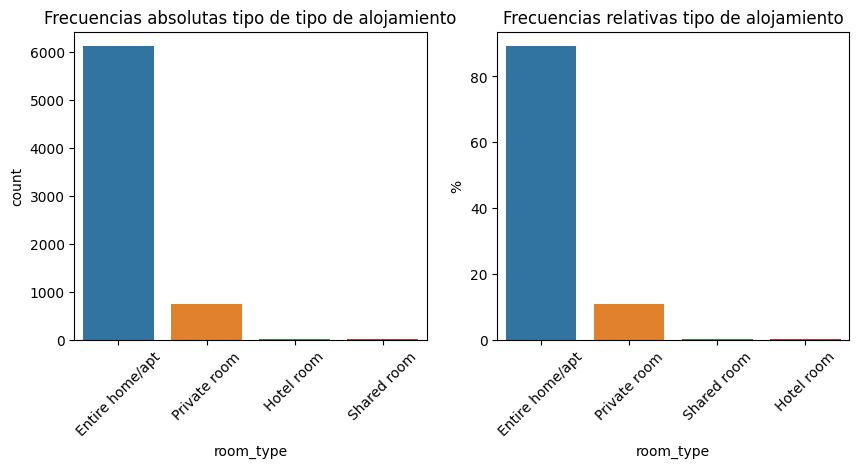

In [21]:
### BARRAS - FRECUENCIAS POR TIPO DE ALOJAMIENTOS

### Creamos figura y axes
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,4))   # Crea una figura con 1 fila y 2 columnas de subplots
fig.suptitle("")                           # Título general para toda la figura

### Countplot, nos permite frecuencias
sns.countplot(                                            
    x="room_type",                                       
    data=df,                                   
    ax=axs[0],                                             
    hue="room_type",                                    
    legend=False                                            
)
axs[0].set_title("Frecuencias absolutas tipo de tipo de alojamiento")
axs[0].tick_params(axis="x", rotation=45)

# Para frecuencias relativas... también hay que calcularlas previamente y puedes usar el barplot
valores = df.room_type.value_counts(normalize=True) * 100   # Calcula % de cada categoría

sns.barplot(                                              
    x=valores.index,                                       
    y=valores.values,                                     
    hue=valores.index,                                       
    ax=axs[1]                                               
)
axs[1].set_title("Frecuencias relativas tipo de alojamiento")        
axs[1].set_ylabel("%")
axs[1].tick_params(axis="x", rotation=45)

plt.show()  

## Frecuencias por **Localización**

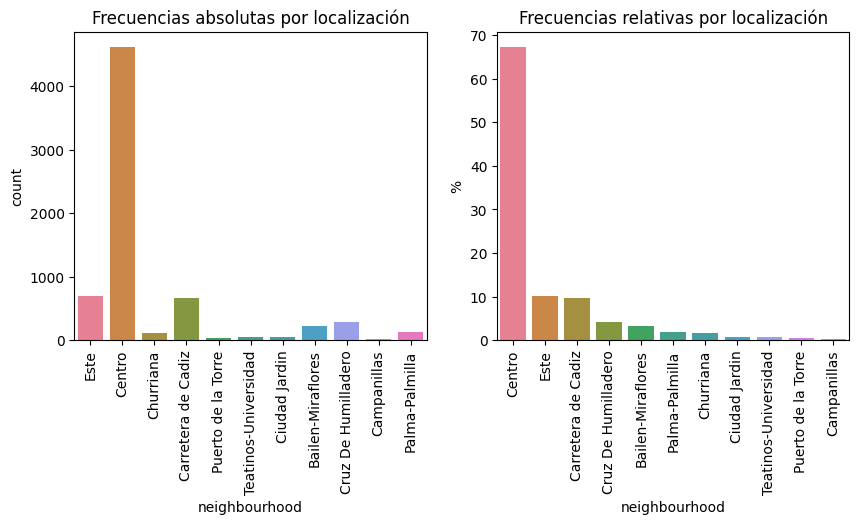

In [20]:
### BARRAS - FRECUENCIAS POR LOCALIZACIÓN

### Creamos figura y axes
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,4))   # Crea una figura con 1 fila y 2 columnas de subplots
fig.suptitle("")                           # Título general para toda la figura

### Countplot, nos permite frecuencias
sns.countplot(                                            
    x="neighbourhood",                                       
    data=df,                                   
    ax=axs[0],                                             
    hue="neighbourhood",                                    
    legend=False                                            
)
axs[0].set_title("Frecuencias absolutas por localización")
axs[0].tick_params(axis="x", rotation=90)

# Para frecuencias relativas... también hay que calcularlas previamente y puedes usar el barplot
valores = df.neighbourhood.value_counts(normalize=True) * 100   # Calcula % de cada categoría

sns.barplot(                                              
    x=valores.index,                                       
    y=valores.values,                                     
    hue=valores.index,                                       
    ax=axs[1]                                               
)
axs[1].set_title("Frecuencias relativas por localización")        
axs[1].set_ylabel("%")
axs[1].tick_params(axis="x", rotation=90)

plt.show()                                                   

## Precio medio por **Localización**

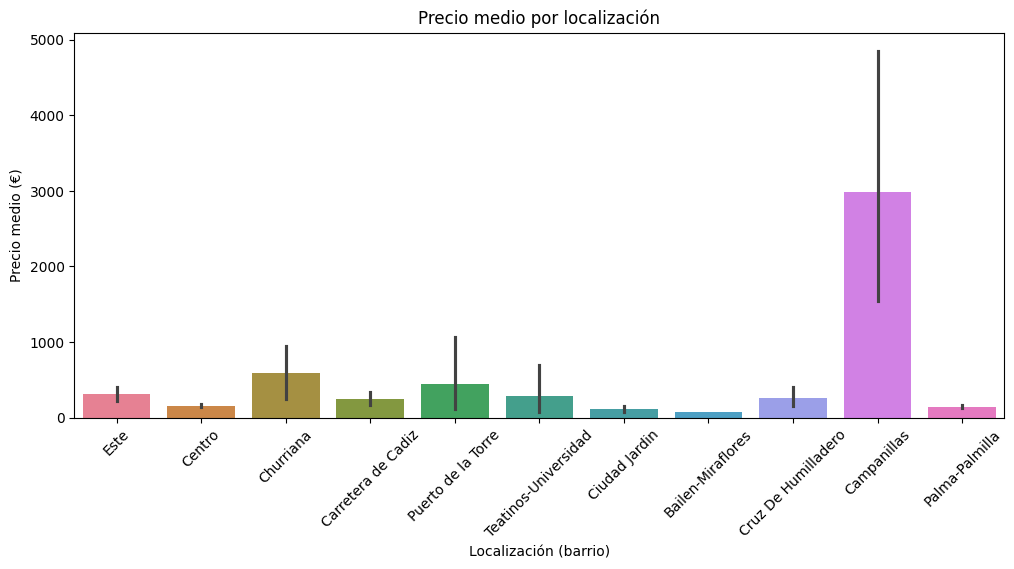

In [15]:
plt.figure(figsize=(12,5))
sns.barplot(
    x="neighbourhood",
    y="price",
    data=df,
    estimator=np.mean,
    hue="neighbourhood",
    legend=False
)
plt.title("Precio medio por localización")
plt.xlabel("Localización (barrio)")
plt.ylabel("Precio medio (€)")
plt.xticks(rotation=45)
plt.show()


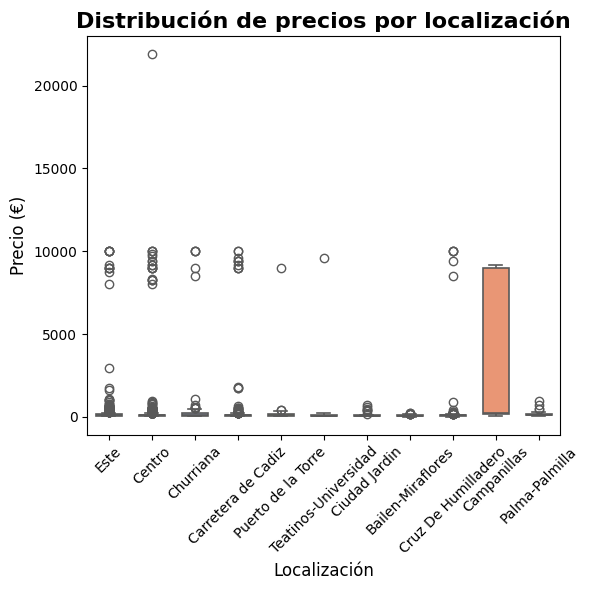

In [20]:
### DIAGRAMA DE CAJAS POR LOCALIZACIÓN Y PRECIO 

plt.figure(figsize=(6,6))   # Crea una figura grande para que el gráfico tenga espacio

sns.boxplot(
    x="neighbourhood",           
    y="price",             
    hue="neighbourhood",         
    data=df,           
    palette="Set2",          
    legend=False,             
    linewidth=1.2,            
    width=0.6                 
)

plt.title("Distribución de precios por localización",
          fontsize=16, weight="bold")   # Título del gráfico

plt.xlabel("Localización", fontsize=12)   # Etiqueta del eje X
plt.ylabel("Precio (€)", fontsize=12)     # Etiqueta del eje Y

plt.xticks(rotation=45)   # Rota las etiquetas del eje X para mejorar la lectura

plt.tight_layout()        # Ajusta márgenes para que nada quede cortado
plt.show()                # Muestra el gráfico

In [27]:
# ¿por qué campanillas tiene los precios mas caros?
# ¿Qué tipo de alojamientos tiene campanillas?

df[df["neighbourhood"]=="Campanillas"]["room_type"].value_counts()

room_type
Entire home/apt    18
Private room        1
Name: count, dtype: int64

In [ ]:
df[df["neighbourhood"]=="Campanillas"]["availability_365"].mean()

np.float64(287.2105263157895)

In [32]:
df[df["neighbourhood"]=="Campanillas"]["price"].mean()

np.float64(2989.2105263157896)

In [23]:
# Campanillas tiene un total de 18 apartamentos completos y una habitación privada con una disponibilidad media de 287 días 
# y un precio medio de 2989 €

## Analisis del PRECIO por UBICACIÓN y TIPO DE ALOJAMIENTO

In [22]:
df.groupby(["neighbourhood", "room_type"])["price"].mean().sort_values(ascending=False)


neighbourhood         room_type      
Campanillas           Entire home/apt    3149.666667
Churriana             Entire home/apt     692.559140
Puerto de la Torre    Entire home/apt     546.478261
Teatinos-Universidad  Entire home/apt     388.848485
Este                  Entire home/apt     328.176744
Cruz De Humilladero   Entire home/apt     327.200913
Carretera de Cadiz    Entire home/apt     298.607076
Centro                Entire home/apt     166.219391
Palma-Palmilla        Entire home/apt     161.611650
Ciudad Jardin         Entire home/apt     139.102564
Campanillas           Private room        101.000000
Bailen-Miraflores     Entire home/apt      84.820359
Carretera de Cadiz    Shared room          58.800000
Cruz De Humilladero   Hotel room           57.000000
Churriana             Private room         56.705882
Centro                Private room         56.377717
Puerto de la Torre    Private room         55.666667
Carretera de Cadiz    Private room         53.104839
Este    

In [31]:
def clasificar_temporada(fecha):
    if pd.isna(fecha):
        return None
    
    mes = fecha.month
    
    if mes in [6, 7, 8]:
        return "Alta"
    elif mes in [3, 4, 5, 9, 10, 11]:
        return "Media"
    else:
        return "Baja"


In [32]:
df["temporada"] = df["last_review"].apply(clasificar_temporada)


In [33]:
df.head()

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,temporada
0,"Bonito piso a 200m de la playa, El Palo (Málaga)",510467,Rafael,Este,Entire home/apt,58.0,3,274,2025-09-29,1.88,1,324,40,ESFCTU0000290200003588210000000000000000VUT/MA...,Media
1,Perfect Location In Malaga,793360,Fred,Este,Private room,28.0,5,102,2025-03-27,0.59,5,288,3,NaN,Media
2,Malaga Lodge Guesthouse Double room-shared bath.,1687526,Mayte,Centro,Private room,60.0,1,68,2025-09-04,0.41,6,64,12,ESHFTU0000290200004234200060000000000000VFT/MA...,Media
3,NEW APARTMENT IN MALAGA CENTER,1725690,Carlos,Centro,Entire home/apt,61.0,3,322,2025-09-09,2.11,1,297,38,VFT/MA/02334,Media
4,Casa La Maga - Apartment for happy people,1526932,Cristina,Centro,Entire home/apt,87.0,2,405,2025-07-27,2.48,1,195,23,VFT/MA/02288,Alta


In [35]:
df.groupby("temporada")["price"].mean()

temporada
Alta     241.384648
Baja     249.936620
Media    175.763848
Name: price, dtype: float64

In [36]:
df["calculated_host_listings_count"].value_counts()

calculated_host_listings_count
1      1613
2       734
3       505
4       316
6       231
5       211
7       186
8       171
220     152
9       141
135     126
86      122
10      109
125     107
59      106
20      103
53       99
63       97
24       88
12       85
44       77
41       74
106      73
13       71
16       68
15       64
38       62
82       58
14       57
28       52
96       51
85       50
25       50
11       49
32       49
62       49
54       48
43       46
18       44
45       43
68       38
40       36
52       36
22       36
49       36
51       33
26       32
19       32
23       31
31       29
29       24
35       16
21       13
27       13
17       11
30        8
Name: count, dtype: int64